# **Automated Financial Fraud & Anomaly Detection Pipeline**
**Author:** Kazim Ali

Model training, evaluation, and explainability notebook (Steps 2–4 of the pipeline).

This notebook covers:
- **Step 2:** Data engineering and class-imbalance handling (SMOTE vs. class weights)
- **Step 3:** ML modeling: Logistic Regression, Isolation Forest, XGBoost, XGBoost+SMOTE
- **Step 4:** Model explainability using SHAP

The trained artifacts produced here feed into the real-time Streamlit dashboard — see `dashboard/app.py`.

## Step 2: Data Engineering & Imbalance Handling

### **2.1 Setup & Data Ingestion**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv('data/creditcard.csv')

print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")
df.head()

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### **2.2 Exploratory Sanity Checks**

In [ ]:
print("Missing values per column:\n", df.isnull().sum().sum())

print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()

print(df[['Time', 'Amount']].describe())

Missing values per column:
 0
Duplicate rows: 1081
                Time         Amount
count  283726.000000  283726.000000
mean    94811.077600      88.472687
std     47481.047891     250.399437
min         0.000000       0.000000
25%     54204.750000       5.600000
50%     84692.500000      22.000000
75%    139298.000000      77.510000
max    172792.000000   25691.160000


### **2.3 Feature Scaling**

In [ ]:
scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

df = df.drop(['Time', 'Amount'], axis=1)
scaled_amount = df.pop('scaled_amount')
scaled_time = df.pop('scaled_time')
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244200,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342584,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.158900,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.139886,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073813,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


### **2.4 Train/Test Split**

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test fraud rate: {y_test.mean()*100:.4f}%")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train fraud rate: 0.1665%
Test fraud rate: 0.1674%
Train shape: (226980, 30), Test shape: (56746, 30)


### **2.5 Baseline Approach: Class Weights (No Resampling)**

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)
print("Baseline model trained (class weights only, no SMOTE).")

Baseline model trained (class weights only, no SMOTE).


### **2.6 SMOTE: Application (Train Set Only)**

In [ ]:
smote = SMOTE(random_state=42, sampling_strategy=0.5)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 113301}


### **2.7 SMOTE Inside a Pipeline (For Cross-Validation)**

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.5)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    smote_pipeline, X_train, y_train,
    cv=cv, scoring='average_precision'
)

print(f"Cross-validated PR-AUC scores: {cv_scores}")
print(f"Mean PR-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-validated PR-AUC scores: [0.77257882 0.74261721 0.71811313 0.75317823 0.79187641]
Mean PR-AUC: 0.7557 (+/- 0.0252)


### **2.8 Save Processed Artifacts**

## Step 3: ML Modeling — Baseline → Isolation Forest → XGBoost

In [ ]:
import joblib
import os

os.makedirs('/content/artifacts', exist_ok=True)


joblib.dump(X_train, '/content/artifacts/X_train.pkl')
joblib.dump(X_test, '/content/artifacts/X_test.pkl')
joblib.dump(y_train, '/content/artifacts/y_train.pkl')
joblib.dump(y_test, '/content/artifacts/y_test.pkl')
joblib.dump(scaler, '/content/artifacts/scaler.pkl')

print("Artifacts saved.")

Artifacts saved.


### **3.1 Load the Artifacts**

In [ ]:
import joblib
import pandas as pd
import numpy as np

X_train = joblib.load('/content/artifacts/X_train.pkl')
X_test = joblib.load('/content/artifacts/X_test.pkl')
y_train = joblib.load('/content/artifacts/y_train.pkl')
y_test = joblib.load('/content/artifacts/y_test.pkl')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (226980, 30), Test: (56746, 30)


### **3.2 Evaluation Helper**

In [ ]:
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, roc_auc_score
)
import matplotlib.pyplot as plt

def evaluate_model(name, y_true, y_pred, y_scores):
    """
    Standard evaluation for imbalanced fraud classification.
    We report PR-AUC and recall/precision — NOT accuracy, which is
    meaningless at a 0.17% fraud rate (a model predicting "no fraud"
    for everything would score 99.8% accuracy and catch zero fraud).
    """
    pr_auc = average_precision_score(y_true, y_scores)
    roc_auc = roc_auc_score(y_true, y_scores)

    print(f"===== {name} =====")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

    return {'name': name, 'pr_auc': pr_auc, 'roc_auc': roc_auc,
            'y_scores': y_scores}

results = []

### **3.3 Model 1: Logistic Regression Baseline (Class Weights)**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_scores_lr = log_reg.predict_proba(X_test)[:, 1]

results.append(evaluate_model("Logistic Regression (Baseline)", y_test, y_pred_lr, y_scores_lr))

===== Logistic Regression (Baseline) =====
PR-AUC:  0.6720
ROC-AUC: 0.9658
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Confusion Matrix:
[[55255  1396]
 [   12    83]]



### **3.4 Model 2: Isolation Forest (Unsupervised Anomaly Detection)**

In [ ]:
from sklearn.ensemble import IsolationForest

fraud_rate = y_train.mean()

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)

raw_pred = iso_forest.predict(X_test)
y_pred_iso = np.where(raw_pred == -1, 1, 0)

y_scores_iso = -iso_forest.decision_function(X_test)

results.append(evaluate_model("Isolation Forest (Unsupervised)", y_test, y_pred_iso, y_scores_iso))

===== Isolation Forest (Unsupervised) =====
PR-AUC:  0.0868
ROC-AUC: 0.9396
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.17      0.18      0.18        95

    accuracy                           1.00     56746
   macro avg       0.59      0.59      0.59     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56569    82]
 [   78    17]]



### **3.5 Model 3: XGBoost**

In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_scores_xgb = xgb_model.predict_proba(X_test)[:, 1]

results.append(evaluate_model("XGBoost", y_test, y_pred_xgb, y_scores_xgb))

scale_pos_weight: 599.48
===== XGBoost =====
PR-AUC:  0.8283
ROC-AUC: 0.9741
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.91      0.78      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56644     7]
 [   21    74]]



### **3.6 Model 4: XGBoost + SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_scores_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

results.append(evaluate_model("XGBoost + SMOTE", y_test, y_pred_xgb_smote, y_scores_xgb_smote))

===== XGBoost + SMOTE =====
PR-AUC:  0.8095
ROC-AUC: 0.9732
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.70      0.80      0.75        95

    accuracy                           1.00     56746
   macro avg       0.85      0.90      0.87     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56618    33]
 [   19    76]]



### **3.7 Comparison of all Models: Precision-Recall Curves**

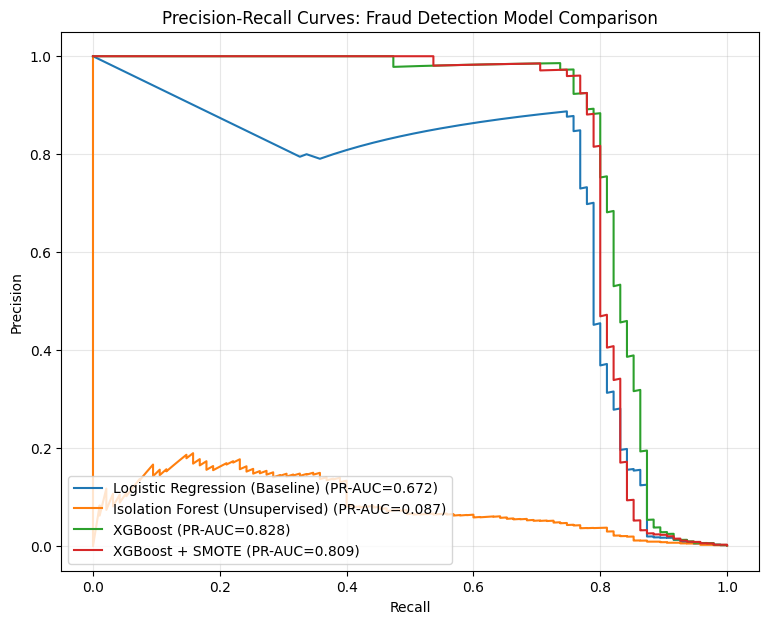

                             Model    PR-AUC   ROC-AUC
0                          XGBoost  0.828290  0.974110
1                  XGBoost + SMOTE  0.809480  0.973193
2   Logistic Regression (Baseline)  0.672011  0.965814
3  Isolation Forest (Unsupervised)  0.086833  0.939619


In [ ]:
plt.figure(figsize=(9, 7))

for r in results:
    precision, recall, _ = precision_recall_curve(y_test, r['y_scores'])
    plt.plot(recall, precision, label=f"{r['name']} (PR-AUC={r['pr_auc']:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves: Fraud Detection Model Comparison')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.savefig('/content/artifacts/pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

comparison_df = pd.DataFrame([{'Model': r['name'], 'PR-AUC': r['pr_auc'], 'ROC-AUC': r['roc_auc']} for r in results])
comparison_df = comparison_df.sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print(comparison_df)

### **3.8 Save the Champion Model**

## Step 4: Model Explainability with SHAP

In [ ]:
champion_model = xgb_model

comparison_df = comparison_df.drop_duplicates(subset='Model', keep='first').reset_index(drop=True)

joblib.dump(champion_model, '/content/artifacts/champion_model.pkl')
comparison_df.to_csv('/content/artifacts/model_comparison.csv', index=False)

print("Champion model saved.")
print(comparison_df)

Champion model saved.
                             Model    PR-AUC   ROC-AUC
0                          XGBoost  0.828290  0.974110
1                  XGBoost + SMOTE  0.809480  0.973193
2   Logistic Regression (Baseline)  0.672011  0.965814
3  Isolation Forest (Unsupervised)  0.086833  0.939619


### **4.1 Install & Load**

In [ ]:
!pip install shap -q

import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

champion_model = joblib.load('/content/artifacts/champion_model.pkl')
X_train = joblib.load('/content/artifacts/X_train.pkl')
X_test = joblib.load('/content/artifacts/X_test.pkl')
y_test = joblib.load('/content/artifacts/y_test.pkl')

explainer = shap.TreeExplainer(champion_model)

### **4.2 Compute SHAP Values**

In [ ]:
np.random.seed(42)

fraud_idx = X_test[y_test == 1].index
legit_idx = X_test[y_test == 0].sample(n=2000, random_state=42).index
sample_idx = fraud_idx.union(legit_idx)

X_shap_sample = X_test.loc[sample_idx]

shap_values = explainer.shap_values(X_shap_sample)

print(f"SHAP values computed for {X_shap_sample.shape[0]} transactions "
      f"({len(fraud_idx)} fraud, {len(legit_idx)} legit)")

SHAP values computed for 2095 transactions (95 fraud, 2000 legit)


### **4.3 Global Feature Importance: Summary Plot**

/tmp/ipykernel_770/2587296065.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, show=False)


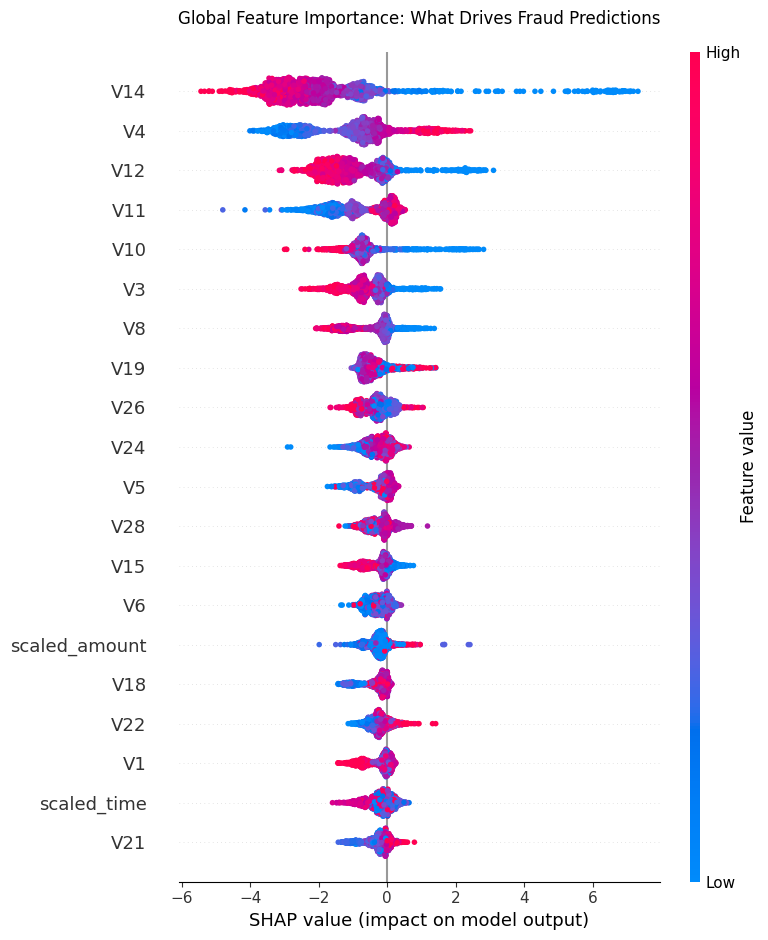

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("Global Feature Importance: What Drives Fraud Predictions", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('/content/artifacts/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### **4.4 Global Feature Importance: Bar Chart View**

/tmp/ipykernel_770/1651576453.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False)


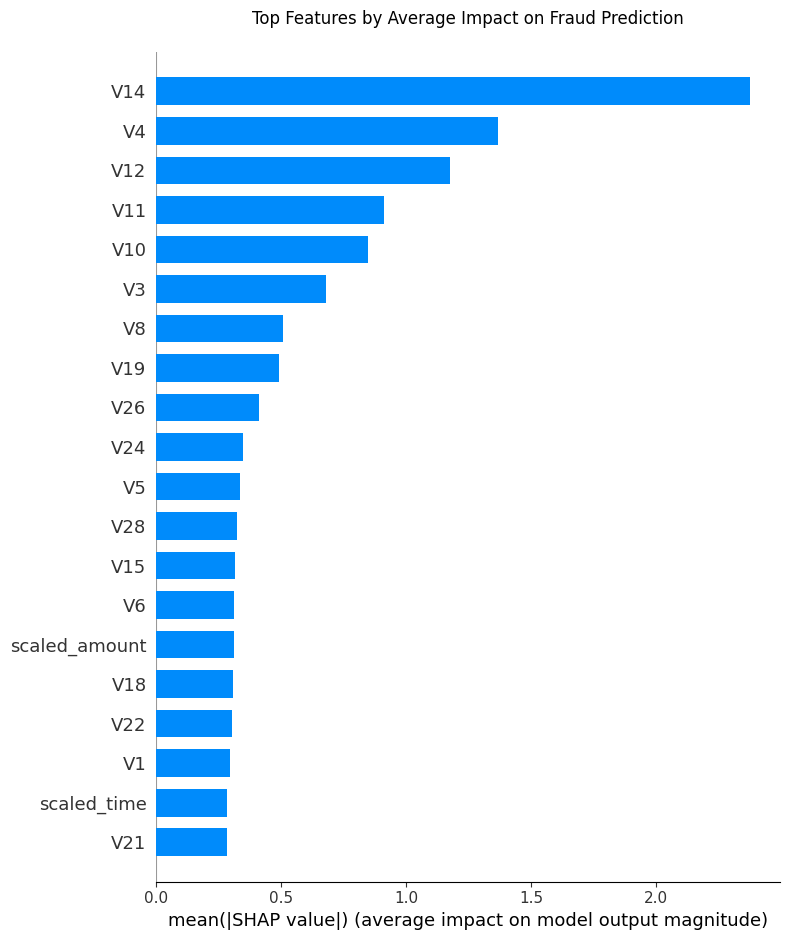

In [ ]:
plt.figure()
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False)
plt.title("Top Features by Average Impact on Fraud Prediction", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig('/content/artifacts/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### **4.5 Local Explanation: "Why Was THIS Transaction Flagged?"**

Transaction Index: 42769
Prediction: FRAUD
Fraud Probability: 100.00%



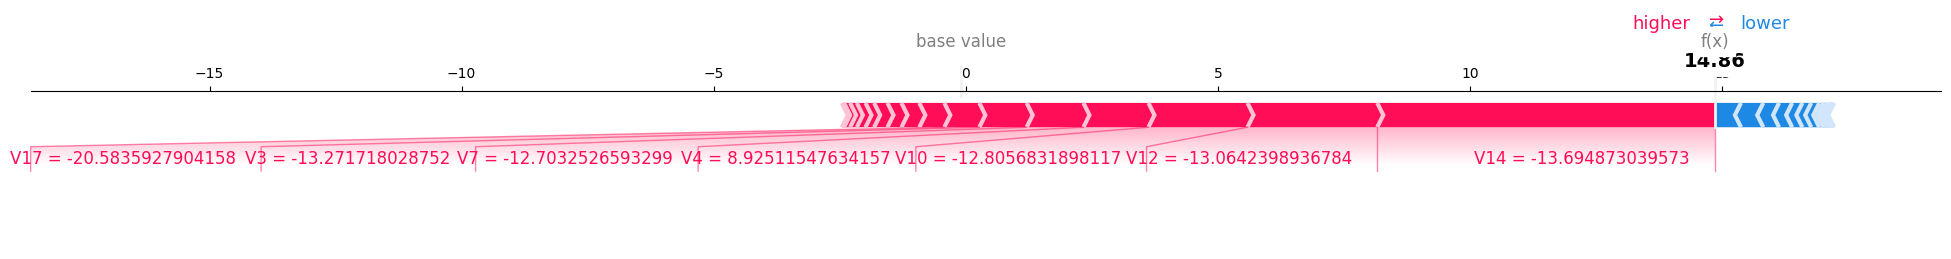

In [ ]:
def explain_transaction(transaction_index, X_data, explainer, model):

    """
    Generates a human-readable SHAP explanation for a single transaction,
    including its predicted fraud probability and a force plot showing
    which features pushed the prediction toward fraud or legitimate.
    """

    transaction = X_data.loc[[transaction_index]]
    prediction = model.predict(transaction)[0]
    probability = model.predict_proba(transaction)[0, 1]

    shap_vals = explainer.shap_values(transaction)

    print(f"Transaction Index: {transaction_index}")
    print(f"Prediction: {'FRAUD' if prediction == 1 else 'LEGITIMATE'}")
    print(f"Fraud Probability: {probability:.2%}")
    print()

    shap.force_plot(
        explainer.expected_value, shap_vals, transaction,
        matplotlib=True, show=False
    )
    plt.tight_layout()
    plt.savefig(f'/content/artifacts/shap_explanation_{transaction_index}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return shap_vals

fraud_probs = champion_model.predict_proba(X_shap_sample)[:, 1]
top_fraud_idx = X_shap_sample.index[np.argmax(fraud_probs)]

shap_vals_example = explain_transaction(top_fraud_idx, X_shap_sample, explainer, champion_model)

In [ ]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_shap_sample.columns,
    'mean_abs_shap_value': mean_abs_shap
}).sort_values('mean_abs_shap_value', ascending=False).reset_index(drop=True)

feature_importance.to_csv('/content/artifacts/shap_feature_importance.csv', index=False)
print(feature_importance.head(10))

  feature  mean_abs_shap_value
0     V14             2.376310
1      V4             1.366985
2     V12             1.173660
3     V11             0.909851
4     V10             0.847116
5      V3             0.679639
6      V8             0.506897
7     V19             0.491534
8     V26             0.409766
9     V24             0.349103


In [ ]:
joblib.dump(explainer, '/content/artifacts/shap_explainer.pkl')
print("SHAP explainer saved.")

SHAP explainer saved.
